## Parte 2 - Ejercicios sobre Números Aleatorios

Realice cada uno de los siguientes ejercicios usando el lenguaje de programación de su preferencia. Pueden usar
Jupyter Notebooks

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import *

#### Tasks 1
Considere un experimento en el cual se cuentan cuántos carros pasan por una calle determinada dentro de un rango de tiempo dado. Sabemos que el tiempo de espera para el n-ésimo evento puede ser modelando a través de una variable gamma. Considere el caso en el que usted está esperando que pase el 3er carro en la calle dada.

1. Para diferentes lambdas en [2, 1, 0.5], grafique las distribuciones gamma para cada uno de los casos.

2. ¿Qué conclusiones puede obtener de las gráficas obtenidas en términos de los tiempos de espera y el número de ocurrencias del evento? ¿Qué relación existe entre el tiempo de espera y el número de ocurrencias de un evento?

In [5]:
k = 3 
lambdas = [2, 1, 0.5] 
scales = [1/l for l in lambdas] 

x = np.linspace(0, 10, 1000)
pdfs = [gamma.pdf(x, a=k, scale=scale) for scale in scales]

print("Lambdas: ", lambdas)
print("Scales: ", scales)
print("PDFs: ", pdfs)

Lambdas:  [2, 1, 0.5]
Scales:  [0.5, 1.0, 2.0]
PDFs:  [array([0.00000000e+00, 3.92856941e-04, 1.54028057e-03, 3.39693918e-03,
       5.91930422e-03, 9.06559060e-03, 1.27956989e-02, 1.70711589e-02,
       2.18550757e-02, 2.71120762e-02, 3.28082581e-02, 3.89111404e-02,
       4.53896147e-02, 5.22138990e-02, 5.93554917e-02, 6.67871282e-02,
       7.44827379e-02, 8.24174030e-02, 9.05673184e-02, 9.89097528e-02,
       1.07423011e-01, 1.16086398e-01, 1.24880182e-01, 1.33785563e-01,
       1.42784635e-01, 1.51860361e-01, 1.60996532e-01, 1.70177747e-01,
       1.79389376e-01, 1.88617536e-01, 1.97849063e-01, 2.07071482e-01,
       2.16272986e-01, 2.25442408e-01, 2.34569199e-01, 2.43643402e-01,
       2.52655632e-01, 2.61597053e-01, 2.70459355e-01, 2.79234737e-01,
       2.87915886e-01, 2.96495957e-01, 3.04968552e-01, 3.13327710e-01,
       3.21567880e-01, 3.29683910e-01, 3.37671031e-01, 3.45524838e-01,
       3.53241278e-01, 3.60816632e-01, 3.68247504e-01, 3.75530808e-01,
       3.82663749e-01,

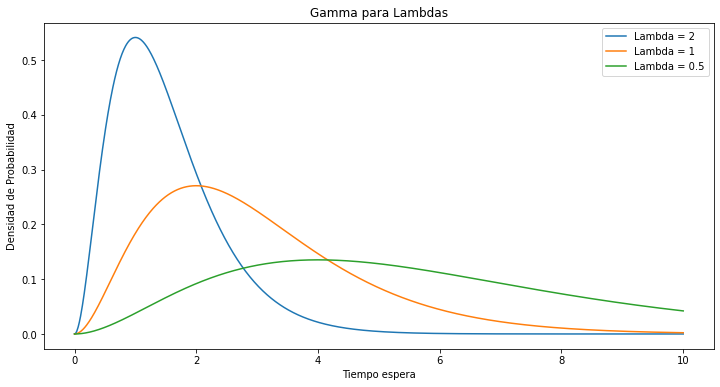

In [7]:
plt.figure(figsize=(12, 6))
for l, pdf in zip(lambdas, pdfs):
    plt.plot(x, pdf, label=f'Lambda = {l}')
plt.title('Gamma para Lambdas')
plt.xlabel('Tiempo espera')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.show()


A raíz de los gráficos obtenidos por medio de la programación realizada en python, se pueden llegar a varias conclusiones. En primer lugar, podemos ver que para Lambda = 2, la campana está centrada aprox en x = 1, y está bastante pronunciada. Sobre todo si se compara con el resto de gráficos. Esto lo que nos dice básicamente es que los tiempos de espera para el tercer carro son más predecibles, y se agrupan en un valor bajo. Su tasa de ocurrencia es alta, y lo más probable es que ese tercer carro pase bastante rápido. Ahora bien, para Lambda = 1, podemos ver que la campana es menos pronunciada que la anterior, lo que también se puede ver es que está centrada al rededor de x = 2. Esto lo podemos tomar en términos prácticos, y como conclusión, como que los tiempos de espera llegan a ser menos predecibles, ya que son más variables, y más largos. Por último, para Lambda = 0.5, podemos ver que la campana tiene una curva bastante plana, visto en que la campana no tiene una forma tan pronunciada como en las anteriores.. Esto nos dice que los tiempos de espera son muy variables, y que el tercer carro puede tardar mucho en pasar. Esto se puede ver en el gráfico, ya que la tasa de ocurrencia es muy baja, y los tiempos de espera son muy variables.

#### Task 2:

Considere las siguientes dos funciones generados de pseudorandoms y responda.

Generador 1:
x_n = 5^5 x_(n-1)  mod(2^35 - 1)
Generador 2:
x_n = 7^5x_(n-1)  mod(2^31 -1)
Y considere al generador de números aleatorios uniformes en (0,1) default de python, como un tercer generador de números aleatorios (Math.random())

1. Construya un programa que compare estos tres generadores a través de un histograma de asteriscos (de 0 a 1 con saltos de 0.1) Use tres comparaciones para 100, 5,000 y 100,000 repeticiones.

2. ¿Qué generador le parece mejor? (considere solamente Generador 1 y Generador 2) ¿Por qué?

In [47]:
import pandas as pd
def generador1(seed, n):
    x = seed
    results = []
    for _ in range(n):
        x = (5**5 * x) % (2**35 - 1)
        results.append(x / (2**35 - 1))
    return results

def generador2(seed, n):
    x = seed
    results = []
    for _ in range(n):
        x = (7**5 * x) % (2**31 - 1)
        results.append(x / (2**31 - 1))
    return results

def generador3(n):
    return np.random.rand(n).tolist()
    
def histograma_asteriscos(datos, generador_nombre):
    bins = [0.1 * i for i in range(11)]
    histograma, _ = np.histogram(datos, bins=bins)
    asteriscos = ['*' * (histograma[i] // (len(datos) // 100)) for i in range(10)]
    intervalos = [f'{i/10}-{(i + 1)/10}' for i in range(10)]
    table_df = pd.DataFrame({'Intervalo': intervalos, 'Asteriscos': asteriscos})
    print(generador_nombre)
    display(table_df)

In [48]:
import pandas as pd

def comparacion(n):
    print(f"Comparación para {n} repeticiones:")
    seed = np.random.randint(1, 1000000)

    datos_gen1 = generador1(seed, n)
    datos_gen2 = generador2(seed, n)
    datos_gen3 = generador3(n)

    print("\nHistograma de asteriscos:")
    histograma_asteriscos(datos_gen1, 'Generador 1')
    histograma_asteriscos(datos_gen2, 'Generador 2')
    histograma_asteriscos(datos_gen3, 'Generador 3')
    
    datos = datos_gen1 + datos_gen2 + datos_gen3
    labels = ['Generador 1'] * n + ['Generador 2'] * n + ['Generador 3'] * n

    df = pd.DataFrame({'Valor': datos, 'Generador': labels})

    plt.figure(figsize=(12, 6))
    sns.histplot(df, x='Valor', hue='Generador', bins=[i/10 for i in range(11)], element='step', stat='density', common_norm=False)
    plt.title(f'Histograma para {n} repeticiones')
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.show()

Comparación para 100 repeticiones:

Histograma de asteriscos:
Generador 1


,Intervalo,Asteriscos
0,0.0-0.1,********
1,0.1-0.2,***********
2,0.2-0.3,**********
3,0.3-0.4,*********
4,0.4-0.5,********
5,0.5-0.6,*******
6,0.6-0.7,***************
7,0.7-0.8,*************
8,0.8-0.9,**********
9,0.9-1.0,*********


Generador 2


,Intervalo,Asteriscos
0,0.0-0.1,**********
1,0.1-0.2,****************
2,0.2-0.3,****
3,0.3-0.4,********
4,0.4-0.5,*************
5,0.5-0.6,**********
6,0.6-0.7,************
7,0.7-0.8,**********
8,0.8-0.9,*********
9,0.9-1.0,********


Generador 3


,Intervalo,Asteriscos
0,0.0-0.1,*********
1,0.1-0.2,**************
2,0.2-0.3,*********
3,0.3-0.4,********
4,0.4-0.5,*********
5,0.5-0.6,**********
6,0.6-0.7,***********
7,0.7-0.8,**********
8,0.8-0.9,**************
9,0.9-1.0,******


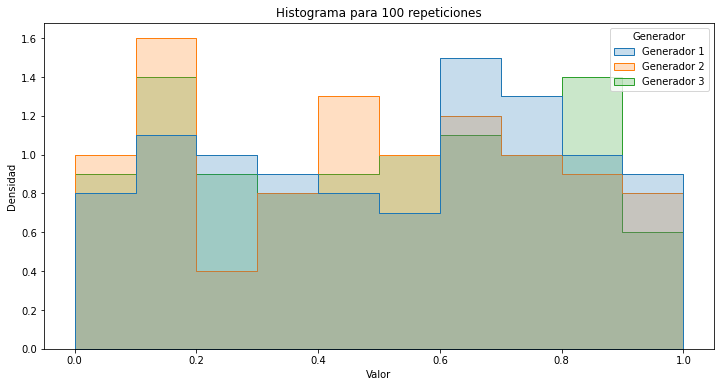

In [49]:
comparacion(100)

Comparación para 5000 repeticiones:

Histograma de asteriscos:
Generador 1


,Intervalo,Asteriscos
0,0.0-0.1,**********
1,0.1-0.2,*********
2,0.2-0.3,**********
3,0.3-0.4,*********
4,0.4-0.5,*********
5,0.5-0.6,*********
6,0.6-0.7,**********
7,0.7-0.8,*********
8,0.8-0.9,***********
9,0.9-1.0,**********


Generador 2


,Intervalo,Asteriscos
0,0.0-0.1,**********
1,0.1-0.2,*********
2,0.2-0.3,**********
3,0.3-0.4,*********
4,0.4-0.5,**********
5,0.5-0.6,*********
6,0.6-0.7,*********
7,0.7-0.8,**********
8,0.8-0.9,*********
9,0.9-1.0,**********


Generador 3


,Intervalo,Asteriscos
0,0.0-0.1,*********
1,0.1-0.2,**********
2,0.2-0.3,**********
3,0.3-0.4,*********
4,0.4-0.5,**********
5,0.5-0.6,**********
6,0.6-0.7,*********
7,0.7-0.8,**********
8,0.8-0.9,**********
9,0.9-1.0,*********


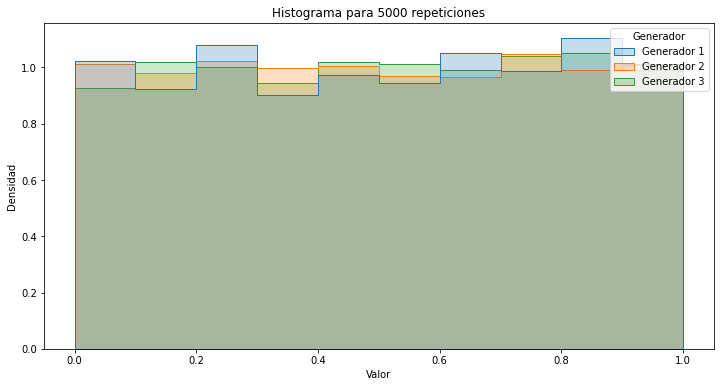

In [50]:
comparacion(5000)

Comparación para 100000 repeticiones:

Histograma de asteriscos:
Generador 1


,Intervalo,Asteriscos
0,0.0-0.1,*********
1,0.1-0.2,**********
2,0.2-0.3,**********
3,0.3-0.4,*********
4,0.4-0.5,**********
5,0.5-0.6,**********
6,0.6-0.7,**********
7,0.7-0.8,*********
8,0.8-0.9,*********
9,0.9-1.0,*********


Generador 2


,Intervalo,Asteriscos
0,0.0-0.1,**********
1,0.1-0.2,**********
2,0.2-0.3,**********
3,0.3-0.4,**********
4,0.4-0.5,**********
5,0.5-0.6,*********
6,0.6-0.7,**********
7,0.7-0.8,*********
8,0.8-0.9,*********
9,0.9-1.0,*********


Generador 3


,Intervalo,Asteriscos
0,0.0-0.1,**********
1,0.1-0.2,**********
2,0.2-0.3,**********
3,0.3-0.4,*********
4,0.4-0.5,**********
5,0.5-0.6,*********
6,0.6-0.7,**********
7,0.7-0.8,*********
8,0.8-0.9,*********
9,0.9-1.0,*********


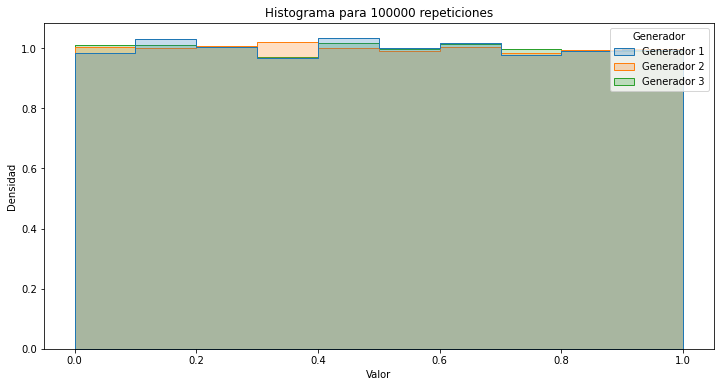

In [51]:
comparacion(100000)

¿Qué generador le parece mejor? (considere solamente Generador 1 y Generador 2) ¿Por qué?

Para verificarlo completamente, primero se realizarán algunas pruebas sobre los generadores, como las de eficiencia y periocidad.


In [53]:
import timeit

n = 10000
seed = 12345

time_gen1 = timeit.timeit('generador1(seed, n)', globals=globals(), number=100)
time_gen2 = timeit.timeit('generador2(seed, n)', globals=globals(), number=100)

print("Tiempo de ejecución Generador 1:", time_gen1)
print("Tiempo de ejecución Generador 2:", time_gen2)


Tiempo de ejecución Generador 1: 0.1104894170020998
Tiempo de ejecución Generador 2: 0.11080191699875286


In [55]:
def find_period(generador, seed):
    n = 1000000  
    generated_values = generador(seed, n)
    seen_values = set()
    
    for value in generated_values:
        if value in seen_values:
            return len(seen_values)
        seen_values.add(value)

    return "No se encontró período en los primeros " + str(n) + " valores."

period_gen1 = find_period(generador1, seed)
period_gen2 = find_period(generador2, seed)

print("Período Generador 1:", period_gen1)
print("Período Generador 2:", period_gen2)


Período Generador 1: 18438
Período Generador 2: No se encontró período en los primeros 1000000 valores.


Basado en lo anterior, podemos decir que en términos de eficiencia son bastante parecidos, por lo cual no será un factor determinante para elegir uno u otro. Ahora bien, en cuanto a la periocidad, podemos decir que favorece al Generador 2, debido a que no muestra una repetición clara en una muestra clara.

Primero transformamos (u y v) para:
y = u . x y x = v'

\begin{align*}
u &= \frac{y}{x} \Rightarrow 0 \leq u \leq 1 \\
v &= x \Rightarrow 0 \leq v \leq \infty \\
dy &= x \, du, \quad dx = dv
\end{align*}
$$\theta = \int_0^\infty \int_0^1 e^{-(v + uv)} v \,du\,dv$$


Ahora transformamos para limites 0 y 1. donde: V = z/1-z

\begin{align*}
v &= \frac{z}{1-z} \Rightarrow 0 \leq z \leq 1 \\
dv &= \frac{dz}{(1-z)^2}
\end{align*}
$$\theta = \int_0^1 \int_0^1 e^{-\left(\frac{z}{1-z} + u \cdot \frac{z}{1-z}\right)} \cdot \frac{z}{(1-z)^3} \,du\,dz$$



In [75]:
from sympy import symbols, integrate, exp

u, v, z = symbols('u v z', real=True, positive=True)

f_uz = exp(-(z/(1-z) + u * z/(1-z))) * (z/(1-z)**3)

result = integrate(integrate(f_uz, (u, 0, 1)), (z, 0, 1))

print("Integral transformada:", result)


Integral transformada: 1/2


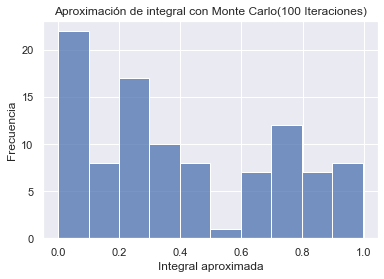

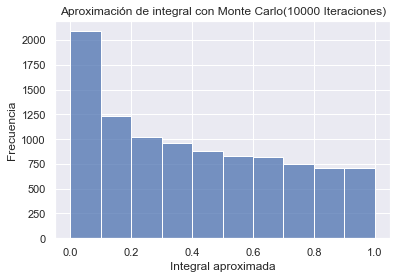

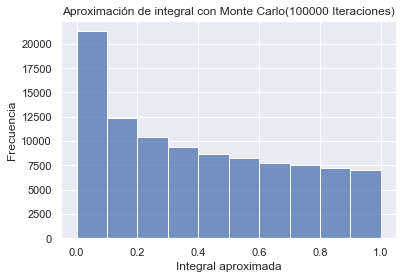

,Iteraciones,Rango,Frecuencia,Porcentaje
0,100,0.0-0.1,22,22.00%
1,100,0.1-0.2,8,8.00%
2,100,0.2-0.3,19,19.00%
3,100,0.3-0.4,8,8.00%
4,100,0.4-0.5,8,8.00%
5,100,0.5-0.6,1,1.00%
6,100,0.6-0.7,7,7.00%
7,100,0.7-0.8,13,13.00%
8,100,0.8-0.9,7,7.00%
9,100,0.9-1.0,7,7.00%


In [86]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def integralOG(x, y):
    return np.exp(-x - y)

def MonteCarlo(iterc):
    results = []
    for _ in range(iterc):
        x = np.random.exponential(scale=1)  
        y = np.random.uniform(0, x)          
        results.append(integralOG(x, y))
    return results

iteraciones = [100, 10000, 100000]
resultadosF = [MonteCarlo(iterc) for iterc in iteraciones]

for iterc, results in zip(iteraciones, resultadosF):
    sns.histplot(results, bins=10, kde=False)
    plt.xlabel('Integral aproximada')
    plt.ylabel('Frecuencia')
    plt.title(f'Aproximación de integral con Monte Carlo({iterc} Iteraciones)')
    plt.show()

infoTabla = []
for iterc, results in zip(iteraciones, resultadosF):
    hist, bin_edges = np.histogram(results, bins=10, range=(0, 1))
    for count, edge in zip(hist, bin_edges[:-1]):
        infoTabla.append((iterc, f"{edge:.1f}-{edge+0.1:.1f}", count, f"{count/iterc*100:.2f}%"))

table_df = pd.DataFrame(infoTabla, columns=['Iteraciones', 'Rango', 'Frecuencia', 'Porcentaje'])
display(table_df)
